# **By Claude**

# 🔬 Topological Data Analysis (TDA) 튜토리얼 — Part 1
## 데이터의 "형태(Shape)"를 측정하다

> **대상**: 머신러닝 스터디 그룹 — TDA를 처음 접하는 분들  
> **사전 지식**: NumPy/Matplotlib 기본, 선형대수 기초  
> **특징**: 외부 TDA 라이브러리 없이 알고리즘을 **처음부터 직접 구현**합니다

---

### 📚 목차

| 섹션 | 주제 |
|------|------|
| § 1 | 위상수학 직관 — 커피컵과 도넛은 같다? |
| § 2 | 단순 복합체(Simplicial Complex) |
| § 3 | 호몰로지(Homology) & 베티 수(Betti numbers) |
| § 4 | 필트레이션(Filtration) 과정 시각화 |
| § 5 | Persistent Homology 이론 |
| § 6 | 처음부터 구현: 경계 행렬 & 열 환원 알고리즘 |
| § 7 | Persistence Diagram & Barcode 해석 |
| § 8 | 다양한 위상 구조 비교 |
| § 9 | 노이즈 강건성 |
| § 10 | 벡터화 → ML 피처 연결 |
| § 11 | 안정성 정리 & Bottleneck Distance |


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon, Circle, FancyArrowPatch
from matplotlib.collections import PatchCollection, LineCollection
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.unicode_minus': False,   # 마이너스 부호 깨짐 방지
})

print("✅ 환경 설정 완료!")
print(f"   NumPy      : {np.__version__}")
print(f"   Matplotlib : {plt.matplotlib.__version__}")
print()
print("📌 이 노트북은 ripser / gudhi 없이 TDA를 처음부터 구현합니다.")
print("   → 알고리즘의 모든 단계를 직접 확인할 수 있습니다.")


✅ 환경 설정 완료!
   NumPy      : 1.26.3
   Matplotlib : 3.8.0

📌 이 노트북은 ripser / gudhi 없이 TDA를 처음부터 구현합니다.
   → 알고리즘의 모든 단계를 직접 확인할 수 있습니다.


In [17]:
# ────────────────────────────────────────────────────────────
# 한국어 폰트 자동 설정
# ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform, os

# ── 플랫폼별 한국어 폰트 후보 목록 ───────────────────────────
KOREAN_FONT_CANDIDATES = {
    'Darwin': [                     # macOS
        'AppleGothic',
        'Apple SD Gothic Neo',
        'Nanum Gothic',
        'NanumGothic',
        'NanumBarunGothic',
    ],
    'Windows': [                    # Windows
        'Malgun Gothic',
        'NanumGothic',
        'Gulim',
        'Dotum',
    ],
    'Linux': [                      # Linux
        'NanumGothic',
        'NanumBarunGothic',
        'UnDotum',
        'UnBatang',
        'Noto Sans CJK KR',
        'Noto Sans KR',
    ],
}

system = platform.system()
candidates = KOREAN_FONT_CANDIDATES.get(system, [])
# 어느 플랫폼이든 공통 후보 추가
candidates += ['NanumGothic', 'Malgun Gothic', 'AppleGothic',
               'Noto Sans CJK KR', 'Noto Sans KR']

# ── 사용 가능한 폰트 탐색 ────────────────────────────────────
available_fonts = {f.name for f in fm.fontManager.ttflist}

selected_font = None
for font_name in candidates:
    if font_name in available_fonts:
        selected_font = font_name
        break

# ── 폰트 적용 ────────────────────────────────────────────────
if selected_font:
    plt.rcParams['font.family'] = selected_font
    plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
    print(f"✅ 한국어 폰트 설정 완료: {selected_font}")
else:
    # 폴백: 영어 레이블로 동작하지만 경고 출력
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠️  한국어 폰트를 찾지 못했습니다. 그래프 레이블이 영어로 표시됩니다.")
    print()
    print("  한국어 폰트 설치 방법:")
    if system == 'Darwin':
        print("    brew install --cask font-nanum-gothic")
        print("    또는: https://hangeul.naver.com/font 에서 나눔고딕 다운로드")
    elif system == 'Linux':
        print("    sudo apt-get install fonts-nanum")
        print("    설치 후: fc-cache -fv  &&  rm ~/.cache/matplotlib/fontlist*.json")
    elif system == 'Windows':
        print("    윈도우에는 기본적으로 맑은고딕(Malgun Gothic)이 있습니다.")
        print("    없다면 나눔고딕: https://hangeul.naver.com/font")
    print()
    print("  설치 후 matplotlib 폰트 캐시 초기화:")
    print("    import matplotlib; import shutil")
    print("    shutil.rmtree(matplotlib.get_cachedir())")
    print("    # 이후 커널 재시작")

print(f"  (현재 플랫폼: {system})")


✅ 한국어 폰트 설정 완료: AppleGothic
  (현재 플랫폼: Darwin)


---
## § 1  위상수학이란? — "형태"의 수학

### 🍩 커피컵 ≅ 도넛

위상수학(Topology)에서는 **연속적인 변형(stretching, bending)**으로 서로 바꿀 수 있는 두 도형을 **같다(homeomorphic)**고 봅니다.  
자르거나 붙이는 것은 허용되지 않습니다.

- **커피컵** ↔ **도넛(토러스)** : 둘 다 구멍이 **1개** → 위상적으로 동일  
- **공(sphere)** : 구멍이 **0개** → 커피컵/도넛과 다름  
- **프레첼** : 구멍이 **2개** → 또 다른 위상 클래스

### 🔑 핵심 아이디어

> **TDA는 데이터 포인트 집합의 "형태"를 수학적으로 측정합니다.**
>
> 좌표계가 바뀌어도, 약간 회전/이동해도,  
> 심지어 약간의 노이즈가 있어도 — **위상적 특징은 변하지 않습니다.**

### 위상 불변량(Topological Invariants) - Betti numbers

| 불변량 | 의미 | 예시 |
|--------|------|------|
| 연결된 성분 수 (β₀) | 몇 개의 덩어리인가? | 분리된 군집 수 |
| 1차원 구멍 수 (β₁) | 루프/사이클이 몇 개인가? | 원형 데이터 구조 |
| 2차원 빈 공간 수 (β₂) | 속이 빈 공동이 몇 개인가? | 구형 껍데기 |


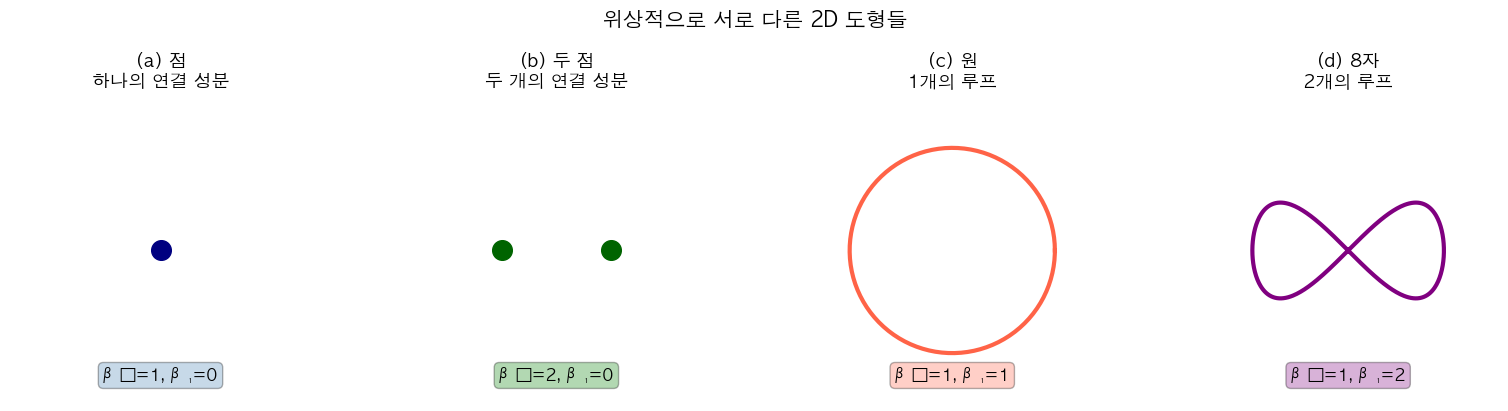

→ β₀: 연결된 덩어리 수  |  β₁: 루프(구멍) 수


In [18]:
# ────────────────────────────────────────────────────────────
# § 1 시각화: 위상 불변량 직관
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("위상적으로 서로 다른 2D 도형들", fontsize=15, y=1.02)

def draw_shape(ax, shape, title, color, betti):
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, pad=10)
    # 베티 수 표시
    ax.text(0, -1.9, f"β₀={betti[0]}, β₁={betti[1]}",
            ha='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

# (a) 점 하나 — β₀=1, β₁=0
ax = axes[0]
ax.scatter([0], [0], s=200, c='navy', zorder=5)
draw_shape(ax, None, "(a) 점\n하나의 연결 성분", 'steelblue', (1, 0))

# (b) 두 점 — β₀=2, β₁=0
ax = axes[1]
ax.scatter([-0.8, 0.8], [0, 0], s=200, c='darkgreen', zorder=5)
draw_shape(ax, None, "(b) 두 점\n두 개의 연결 성분", 'green', (2, 0))

# (c) 원 — β₀=1, β₁=1
ax = axes[2]
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta)*1.5, np.sin(theta)*1.5, 'tomato', lw=3)
draw_shape(ax, None, "(c) 원\n1개의 루프", 'tomato', (1, 1))

# (d) 8자 — β₀=1, β₁=2
ax = axes[3]
t = np.linspace(0, 2*np.pi, 400)
x = np.sin(t)*1.4
y = np.sin(t)*np.cos(t)*1.4
ax.plot(x, y, 'purple', lw=3)
draw_shape(ax, None, "(d) 8자\n2개의 루프", 'purple', (1, 2))

plt.tight_layout()
plt.savefig('/tmp/fig_topology_intuition.png', dpi=130, bbox_inches='tight')
plt.show()
print("→ β₀: 연결된 덩어리 수  |  β₁: 루프(구멍) 수")


**문제!**
*다음의 Betti Number을 맞춰보세요*

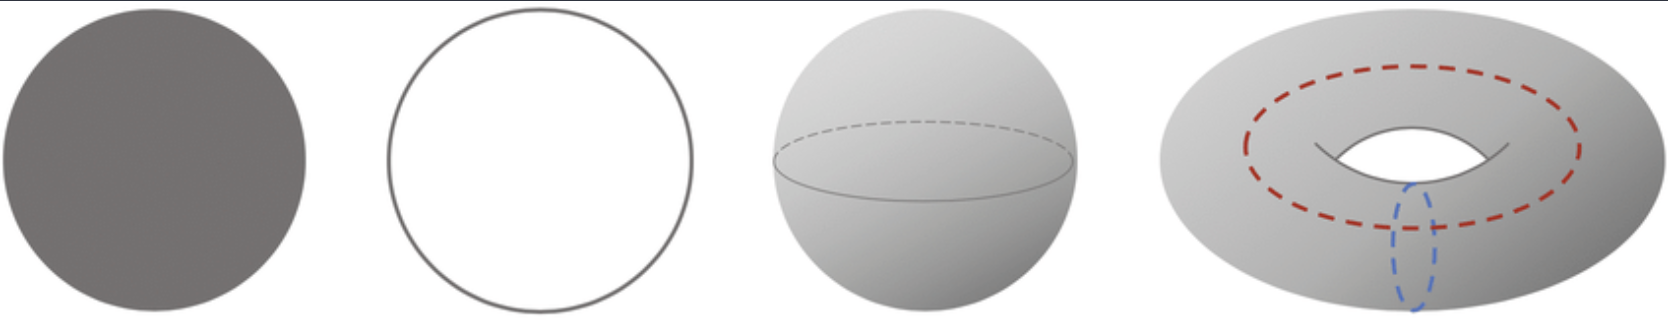






*정답:*
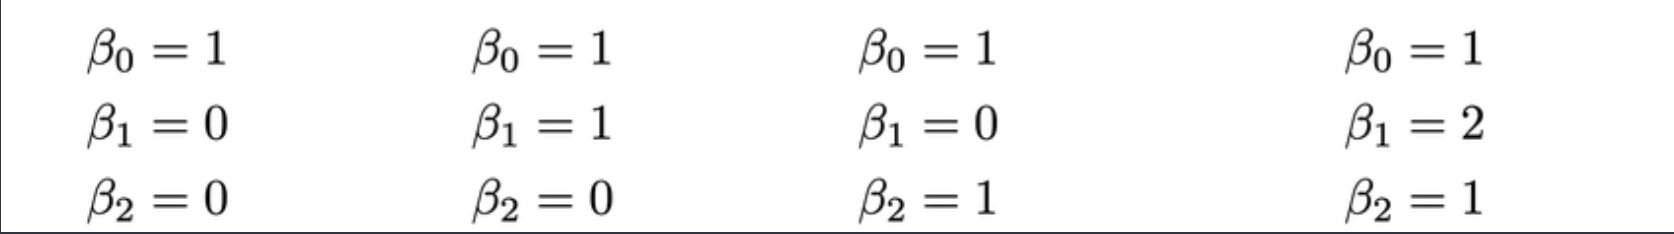

.

.

.

*추가학습*

**속이 찬 도넛 (Solid Torus, $D^2 \times S^1$)**:
- **$\beta_0 = 1$** (연결 성분)
- **$\beta_1 = 1$** (가운데 뚫린 구멍)
- **$\beta_2 = 0$** (속이 비어있지 않음)


---
## § 2  단순 복합체(Simplicial Complex)

데이터 포인트를 직접 다루기 위해 점들을 **단순체(simplex)**로 연결합니다.

| 차원 | 이름 | 기호 | 의미 |
|------|------|------|------|
| 0 | 꼭짓점 | v | 데이터 포인트 하나 |
| 1 | 모서리 | [v₀, v₁] | 두 점 연결 |
| 2 | 삼각형 | [v₀, v₁, v₂] | 면 채우기 |
| 3 | 사면체 | [v₀, v₁, v₂, v₃] | 3D 공간 채우기 |

**단순 복합체** = 이러한 단순체들의 집합 (경계 단순체도 포함)

### Vietoris-Rips Complex

가장 많이 쓰이는 방법: 반경 ε 안에 있는 모든 점들을 연결

$$V\!R(\varepsilon) = \{\sigma \subseteq X \ |\ d(u, v) \leq \varepsilon, \ \forall u,v \in \sigma\}$$


$$V\!R(\varepsilon) = \{\sigma \subseteq X \ |\ d(u, v) \leq \varepsilon, \ \forall u,v \in \sigma\}$$

* **$V\!R(\varepsilon)$**: "반지름(정확히는 지름) $\varepsilon$짜리 안경을 쓰고 본 데이터의 모양"
* **$\{\sigma \subseteq X \ | \ \dots \}$**: "전체 점 집합 $X$에서 몇 개의 점을 뽑아 만든 부분집합($\sigma$)들을 모을 건데, 그 조건($|$)은 다음과 같다."
* **$d(u, v) \leq \varepsilon$**: "두 점 사이의 거리($d$)가 $\varepsilon$보다 작거나 같아야 한다."
* **$\forall u,v \in \sigma$**: "**$\sigma$ 안에 있는 모든 점 쌍(Every pair)**에 대해서 위 조건이 성립해야 한다."


> **"내가 뽑은 점들 중에서 어떤 두 점을 골라도 그 거리가 $\varepsilon$ 이하라면, 그 점들을 묶어서 하나의 '단순체(Simplex)'로 인정해주겠다!"** 


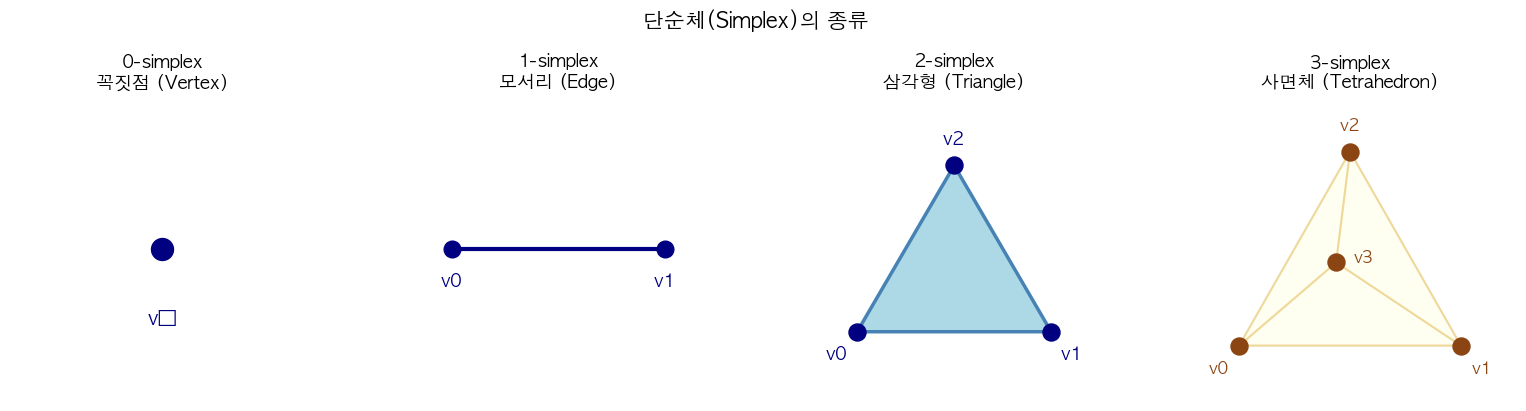

In [19]:
# ────────────────────────────────────────────────────────────
# § 2 시각화: 단순체(Simplex) 개념
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("단순체(Simplex)의 종류", fontsize=15, y=1.02)

colors = {'vertex': 'navy', 'edge': 'steelblue', 'face': 'lightblue', 'tet': 'lightyellow'}

# (a) 0-simplex: 꼭짓점
ax = axes[0]
ax.scatter([0], [0], s=250, c=colors['vertex'], zorder=5)
ax.set_title("0-simplex\n꼭짓점 (Vertex)")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect('equal'); ax.axis('off')
ax.text(0, -0.5, "v₀", ha='center', fontsize=14, color='navy')

# (b) 1-simplex: 모서리
ax = axes[1]
pts = np.array([[-0.7, 0], [0.7, 0]])
ax.plot(pts[:,0], pts[:,1], 'o-', c=colors['vertex'], lw=3, ms=12, mfc=colors['vertex'])
ax.set_title("1-simplex\n모서리 (Edge)")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1, 1); ax.set_aspect('equal'); ax.axis('off')
for i, (x,y) in enumerate(pts):
    ax.text(x, y-0.25, f"v{i}", ha='center', fontsize=13, color='navy')

# (c) 2-simplex: 삼각형
ax = axes[2]
pts = np.array([[-0.7, -0.5], [0.7, -0.5], [0, 0.7]])
tri = Polygon(pts, closed=True, facecolor=colors['face'], edgecolor=colors['edge'], lw=2.5)
ax.add_patch(tri)
ax.scatter(pts[:,0], pts[:,1], s=150, c=colors['vertex'], zorder=5)
ax.set_title("2-simplex\n삼각형 (Triangle)")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1, 1.2); ax.set_aspect('equal'); ax.axis('off')
for i, (x,y) in enumerate(pts):
    offsets = [(-0.15,-0.2),(0.15,-0.2),(0,0.15)]
    ax.text(x+offsets[i][0], y+offsets[i][1], f"v{i}", ha='center', fontsize=13, color='navy')

# (d) 3-simplex: 사면체 (2D 투영)
ax = axes[3]
pts3d = np.array([[-0.8,-0.6],[0.8,-0.6],[0.0,0.8],[-0.1,0.0]])
alpha_face = 0.25
# 아래 삼각형
for tri_idx in [(0,1,2),(0,1,3),(0,2,3),(1,2,3)]:
    tri = Polygon(pts3d[list(tri_idx)], closed=True,
                  facecolor='lightyellow', edgecolor='goldenrod', lw=1.5, alpha=alpha_face)
    ax.add_patch(tri)
ax.scatter(pts3d[:,0], pts3d[:,1], s=150, c='saddlebrown', zorder=5)
ax.set_title("3-simplex\n사면체 (Tetrahedron)")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1, 1.2); ax.set_aspect('equal'); ax.axis('off')
labels_off = [(-0.15,-0.2),(0.15,-0.2),(0,0.15),(0.2,0.0)]
for i, (x,y) in enumerate(pts3d):
    ax.text(x+labels_off[i][0], y+labels_off[i][1], f"v{i}", ha='center', fontsize=12, color='saddlebrown')

plt.tight_layout()
plt.savefig('/tmp/fig_simplices.png', dpi=130, bbox_inches='tight')
plt.show()


### 핵심 함수 모음

아래 코드 셀에서 이 노트북 전체에서 사용할 **TDA 핵심 함수들**을 정의합니다.

- `pairwise_dist(X)` — 점 집합의 모든 쌍 거리 행렬
- `vr_complex(X, eps)` — ε에서의 VR 복합체 (모서리·삼각형 목록)
- `draw_vr_complex(ax, X, eps)` — VR 복합체 시각화
- 데이터 생성기: `make_circle`, `make_two_circles`, `make_torus`, `make_random`


In [20]:
# ────────────────────────────────────────────────────────────
# § 2 핵심 헬퍼 함수 정의
# ────────────────────────────────────────────────────────────

# ── 1. 거리 행렬 ─────────────────────────────────────────────
def pairwise_dist(X):
    """모든 점 쌍 사이의 유클리드 거리 행렬 반환 (n x n)"""
    X = np.array(X, dtype=float)
    diff = X[:, None, :] - X[None, :, :]   # (n, n, d)
    return np.sqrt((diff**2).sum(axis=-1))


# ── 2. VR 복합체 구성 ────────────────────────────────────────
def vr_complex(X, eps):
    """\n    ε 에서의 Vietoris-Rips Complex 반환\n    Returns: edges (list of (i,j)), triangles (list of (i,j,k))\n    """
    n = len(X)
    D = pairwise_dist(X)
    edges     = [(i, j) for i, j in combinations(range(n), 2) if D[i,j] <= eps]
    triangles = [(i, j, k) for i, j, k in combinations(range(n), 3)
                 if max(D[i,j], D[i,k], D[j,k]) <= eps]
    return edges, triangles


# ── 3. VR 복합체 시각화 ──────────────────────────────────────
def draw_vr_complex(ax, X, eps, title=None,
                    pt_color='navy', edge_color='steelblue',
                    face_color='#9ecae1', show_circles=True):
    """단일 ε 값에서의 VR 복합체를 그린다"""
    X = np.array(X)
    D = pairwise_dist(X)
    edges, triangles = vr_complex(X, eps)

    # 원(coverage) 그리기
    if show_circles:
        for pt in X:
            c = Circle(pt, eps/2, color=edge_color, alpha=0.07, linewidth=0)
            ax.add_patch(c)
            c2 = Circle(pt, eps/2, fill=False, edgecolor=edge_color, lw=0.8, alpha=0.4)
            ax.add_patch(c2)

    # 삼각형 채우기
    for (i, j, k) in triangles:
        tri = Polygon(X[[i,j,k]], closed=True,
                      facecolor=face_color, edgecolor=edge_color, lw=0, alpha=0.5)
        ax.add_patch(tri)

    # 모서리
    for (i, j) in edges:
        ax.plot(*X[[i,j]].T, '-', color=edge_color, lw=1.8, alpha=0.7, zorder=3)

    # 꼭짓점
    ax.scatter(X[:,0], X[:,1], c=pt_color, s=60, zorder=5, edgecolors='white', lw=1)

    # 베티 수 계산 (간단 버전)
    if title:
        ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.axis('off')


# ── 4. 데이터 생성기들 ───────────────────────────────────────
def make_circle(n=30, r=1.0, noise=0.0, seed=42):
    """단위 원 위의 균일 샘플"""
    np.random.seed(seed)
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    pts = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
    if noise > 0:
        pts += noise * np.random.randn(n, 2)
    return pts

def make_two_circles(n=40, noise=0.05, seed=42):
    """크기가 다른 두 원"""
    c1 = make_circle(n//2, r=1.0, noise=noise, seed=seed)   + [-1.5, 0]
    c2 = make_circle(n//2, r=0.6, noise=noise, seed=seed+1) + [ 1.5, 0]
    return np.vstack([c1, c2])

def make_torus_2d(n=40, noise=0.05, seed=42):
    """\n    토러스(Torus)를 2D에 투영한 근사: 두 동심원\n    (진짜 토러스는 3D에서 정의되지만, 2D에서는 두 동심원으로 근사 가능)\n    """
    np.random.seed(seed)
    inner = make_circle(n//2, r=0.7, noise=noise, seed=seed)
    outer = make_circle(n//2, r=1.4, noise=noise, seed=seed+1)
    return np.vstack([inner, outer])

def make_random(n=30, scale=1.5, seed=42):
    """가우시안 랜덤 점구름"""
    np.random.seed(seed)
    return np.random.randn(n, 2) * scale

def make_three_clusters(n=45, noise=0.15, seed=42):
    """세 개의 클러스터"""
    np.random.seed(seed)
    centers = np.array([[-2, 0], [2, 0], [0, 2.5]])
    pts = []
    for c in centers:
        pts.append(c + noise * np.random.randn(n//3, 2) * 5)
    return np.vstack(pts)

print("✅ 헬퍼 함수 정의 완료!")
print("   - pairwise_dist(X)")
print("   - vr_complex(X, eps)")
print("   - draw_vr_complex(ax, X, eps, ...)")
print("   - make_circle / make_two_circles / make_torus_2d / make_random / make_three_clusters")


✅ 헬퍼 함수 정의 완료!
   - pairwise_dist(X)
   - vr_complex(X, eps)
   - draw_vr_complex(ax, X, eps, ...)
   - make_circle / make_two_circles / make_torus_2d / make_random / make_three_clusters


### VR Complex의 성장 과정

ε 을 0에서 점점 키우면 VR 복합체가 어떻게 **성장**하는지 관찰해 봅시다.  
처음에는 고립된 점들만 있다가, 가까운 점들이 연결되고, 삼각형이 채워집니다.


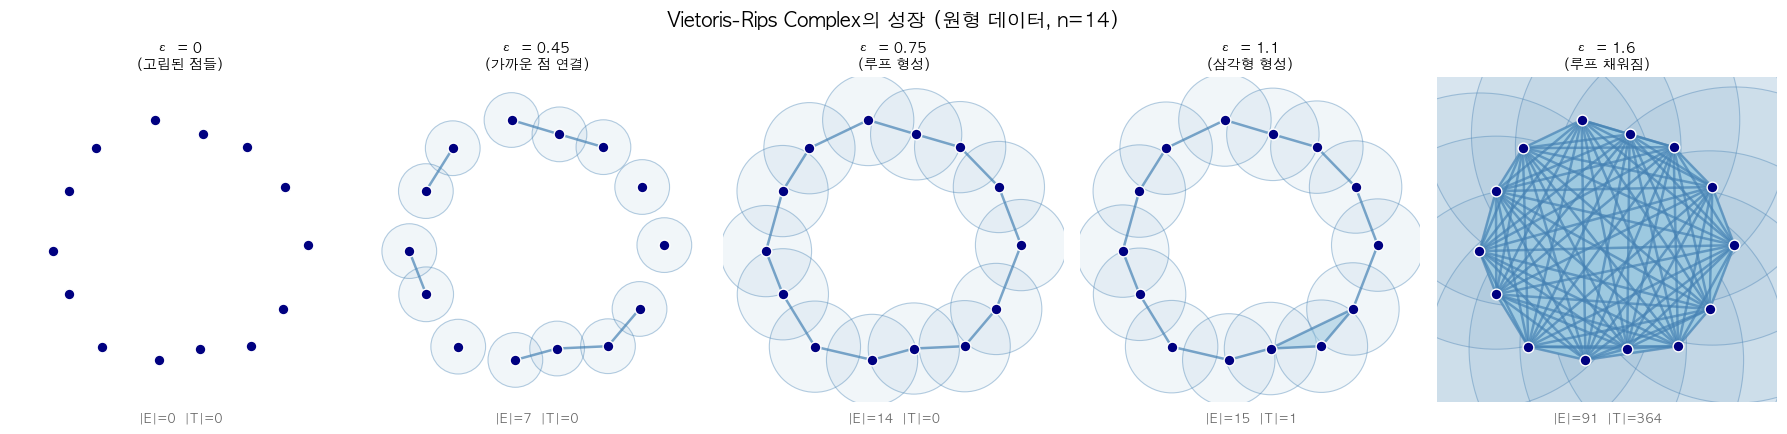

→ ε가 커질수록 단순 복합체가 성장합니다.
   작은 ε: 점들 분리  →  중간 ε: 원의 루프 형성  →  큰 ε: 완전히 채워짐


In [42]:
# ────────────────────────────────────────────────────────────
# § 2 VR Complex 성장 시각화
# ────────────────────────────────────────────────────────────

X_circle = make_circle(n=14, noise=0.05, seed=7)
epsilons = [0.0, 0.45, 0.75, 0.76, 2.6]
labels   = ['ε = 0\n(고립된 점들)', 'ε = 0.45\n(가까운 점 연결)', 
            'ε = 0.75\n(루프 형성)', 'ε = 1.1\n(삼각형 형성)', 
            'ε = 1.6\n(루프 채워짐)']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Vietoris-Rips Complex의 성장 (원형 데이터, n=14)", fontsize=14, y=1.03)

pad = 0.35
xlim = (X_circle[:,0].min()-pad, X_circle[:,0].max()+pad)
ylim = (X_circle[:,1].min()-pad, X_circle[:,1].max()+pad)

for ax, eps, lbl in zip(axes, epsilons, labels):
    draw_vr_complex(ax, X_circle, eps, show_circles=True)
    edges, triangles = vr_complex(X_circle, eps)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    # 정보 표시
    info = f"|E|={len(edges)}  |T|={len(triangles)}"
    ax.text(0.5, -0.06, info, transform=ax.transAxes,
            ha='center', fontsize=9, color='dimgray')

plt.tight_layout()
plt.savefig('/tmp/fig_vr_growth.png', dpi=130, bbox_inches='tight')
plt.show()
print("→ ε가 커질수록 단순 복합체가 성장합니다.")
print("   작은 ε: 점들 분리  →  중간 ε: 원의 루프 형성  →  큰 ε: 완전히 채워짐")


---
## § 3  호몰로지(Homology) & 베티 수(Betti Numbers)

### 직관적 이해

**호몰로지**는 위상 공간의 "구멍"을 체계적으로 분류하는 대수적 도구입니다.

$$H_k(X) = \ker(\partial_k) / \text{im}(\partial_{k+1})$$

여기서 $\partial_k$ 는 **경계 연산자(boundary operator)** 입니다.  
"경계가 없는 것들(cycles)" 중에서 "다른 것의 경계인 것들"을 빼면 진짜 구멍만 남습니다.

$H_k = \ker / \text{im}$ : "진짜 구멍"을 찾는 나눗셈왜 사이클($\ker$)을 경계($\text{im}$)로 나누는 걸까요?

- $\ker$ (사이클): 일단 닫혀 있는 모양들을 다 모읍니다. (구멍 후보들)
- $\text{im}$ (경계): 그중에서 안쪽이 삼각형이나 사면체로 꽉 채워진(Filled) 녀석들을 골라냅니다.
- 결과 ($H_k$): **"닫혀는 있는데($\ker$), 안쪽이 채워지지는 않은($\text{im}$이 아닌) 녀석들"**만 남습니다. 이게 바로 우리가 찾는 **'진짜 구멍'**입니다.

💡 비유:
    "$\ker$는 '닫힌 울타리'이고, $\text{im}$은 그 울타리 안에 채워진 '마당'입니다. 울타리는 있는데 마당이 없는 상태, 즉 속이 텅 빈 울타리만이 우리는 위상학적으로 '구멍'이라고 부릅니다."

### 베티 수 (Betti Numbers)

$$\beta_k = \text{rank}(H_k)$$

$\text{rank}$ (계수/차원): 선형대수에서 랭크는 "서로 독립적인 벡터가 몇 개인가?"를 묻는 것이죠. 

TDA에서는 **"다른 구멍들을 합쳐서 만들 수 없는, 독보적인 구멍이 몇 개인가?"**를 묻는 것입니다.

$\beta_k$ (베티 수): 그 질문에 대한 **최종 답변(숫자)**입니다.

| 베티 수 | 의미 | 직관 |
|---------|------|------|
| **β₀** | 연결된 성분의 수 | 덩어리가 몇 개? |
| **β₁** | 1차원 루프/사이클의 수 | 구멍이 몇 개? |
| **β₂** | 2차원 빈 공동의 수 | 속이 빈 구면 몇 개? |



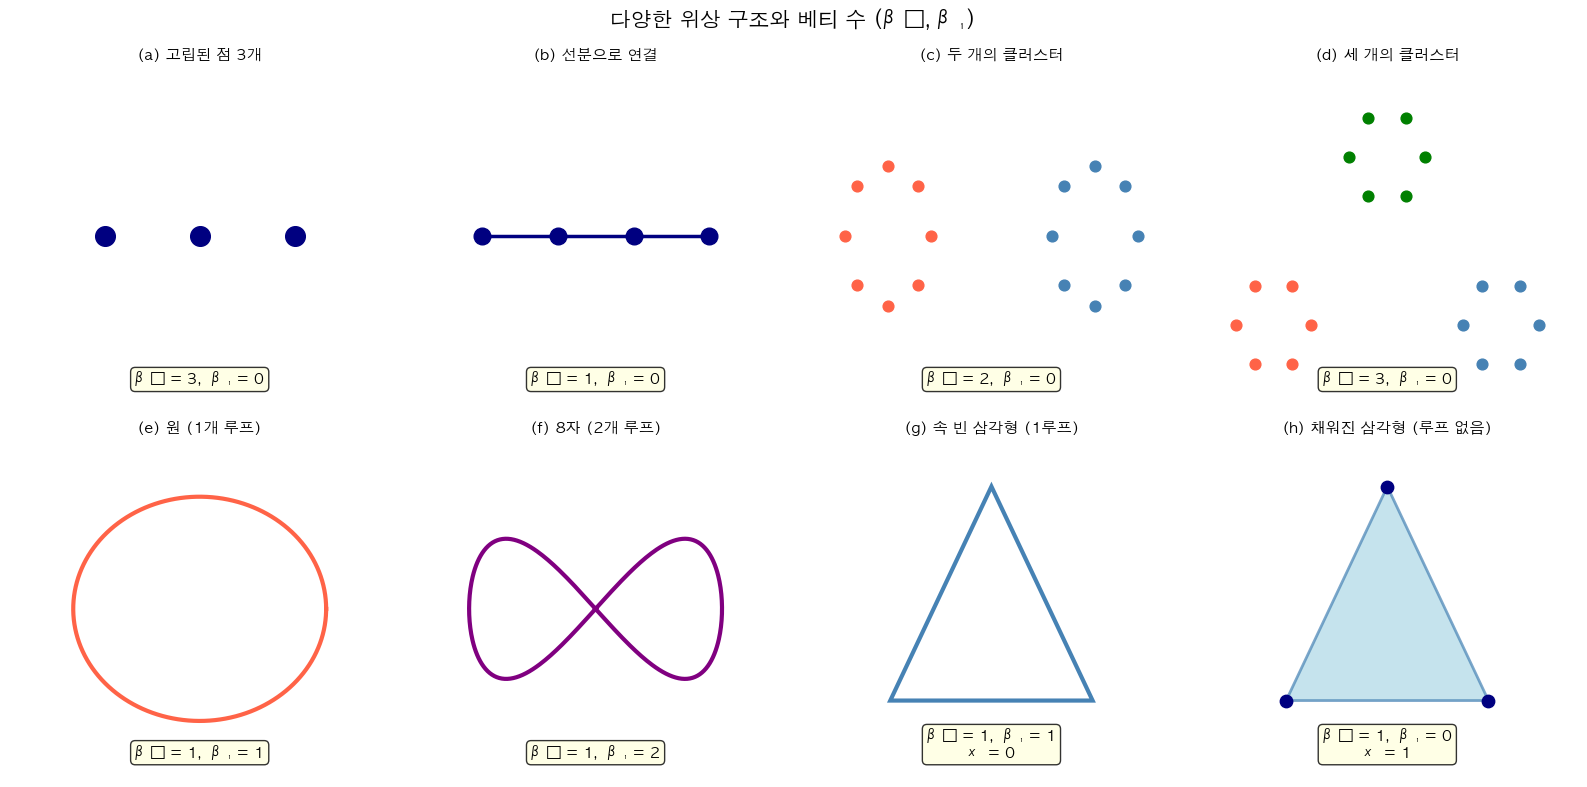

In [22]:
# ────────────────────────────────────────────────────────────
# § 3 베티 수 직관 시각화
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("다양한 위상 구조와 베티 수 (β₀, β₁)", fontsize=15)

def annotate_betti(ax, b0, b1, chi=None):
    txt = f"β₀ = {b0},  β₁ = {b1}"
    if chi is not None:
        txt += f"\nχ = {chi}"
    ax.text(0.5, 0.05, txt, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

theta = np.linspace(0, 2*np.pi, 300)

# ── 상단 행: β₀ 예시 ─────────────────────────────────────────
# (a) 점 3개
ax = axes[0,0]
ax.scatter([-1,0,1],[0,0,0], s=200, c='navy')
ax.set_xlim(-2,2); ax.set_ylim(-1.5,1.5); ax.axis('off')
ax.set_title("(a) 고립된 점 3개", fontsize=11)
annotate_betti(ax, 3, 0)

# (b) 연결된 선
ax = axes[0,1]
pts = np.array([[-1.2,0],[-0.4,0],[0.4,0],[1.2,0]])
ax.plot(pts[:,0], pts[:,1], 'o-', c='navy', lw=2.5, ms=12)
ax.set_xlim(-2,2); ax.set_ylim(-1.5,1.5); ax.axis('off')
ax.set_title("(b) 선분으로 연결", fontsize=11)
annotate_betti(ax, 1, 0)

# (c) 두 클러스터
ax = axes[0,2]
c1 = make_circle(8, r=0.5, noise=0.0) + [-1.2, 0]
c2 = make_circle(8, r=0.5, noise=0.0) + [1.2, 0]
ax.scatter(c1[:,0], c1[:,1], c='tomato', s=60)
ax.scatter(c2[:,0], c2[:,1], c='steelblue', s=60)
ax.set_xlim(-2.2,2.2); ax.set_ylim(-1.2,1.2); ax.axis('off')
ax.set_title("(c) 두 개의 클러스터", fontsize=11)
annotate_betti(ax, 2, 0)

# (d) 세 클러스터
ax = axes[0,3]
for i, (cx, cy) in enumerate([(-1.2,-0.5),(1.2,-0.5),(0,1.0)]):
    pts_c = make_circle(6, r=0.4, noise=0.0) + [cx, cy]
    ax.scatter(pts_c[:,0], pts_c[:,1], s=60,
               c=['tomato','steelblue','green'][i])
ax.set_xlim(-2,2); ax.set_ylim(-1.2,1.8); ax.axis('off')
ax.set_title("(d) 세 개의 클러스터", fontsize=11)
annotate_betti(ax, 3, 0)

# ── 하단 행: β₁ 예시 ─────────────────────────────────────────
# (e) 원 (루프 1개)
ax = axes[1,0]
ax.plot(np.cos(theta), np.sin(theta), 'tomato', lw=3)
ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.axis('off')
ax.set_title("(e) 원 (1개 루프)", fontsize=11)
annotate_betti(ax, 1, 1)

# (f) 8자 (루프 2개)
ax = axes[1,1]
t = np.linspace(0, 2*np.pi, 400)
ax.plot(np.sin(t), np.sin(t)*np.cos(t), 'purple', lw=3)
ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.2,1.2); ax.axis('off')
ax.set_title("(f) 8자 (2개 루프)", fontsize=11)
annotate_betti(ax, 1, 2)

# (g) 삼각형 (채워진 vs. 빈)
ax = axes[1,2]
# 속이 빈 삼각형
tri_pts = np.array([[0, 0.9], [-0.8, -0.5], [0.8, -0.5]])
tri_open = Polygon(tri_pts, closed=True, fill=False, edgecolor='steelblue', lw=3)
ax.add_patch(tri_open)
ax.set_xlim(-1.5,1.5); ax.set_ylim(-1,1.2); ax.axis('off')
ax.set_title("(g) 속 빈 삼각형 (1루프)", fontsize=11)
annotate_betti(ax, 1, 1, chi=0)

# (h) 채워진 삼각형 (루프 없음)
ax = axes[1,3]
tri_filled = Polygon(tri_pts, closed=True,
                     facecolor='lightblue', edgecolor='steelblue', lw=2, alpha=0.7)
ax.add_patch(tri_filled)
ax.scatter(tri_pts[:,0], tri_pts[:,1], c='navy', s=80, zorder=5)
ax.set_xlim(-1.5,1.5); ax.set_ylim(-1,1.2); ax.axis('off')
ax.set_title("(h) 채워진 삼각형 (루프 없음)", fontsize=11)
annotate_betti(ax, 1, 0, chi=1)

plt.tight_layout()
plt.savefig('/tmp/fig_betti.png', dpi=130, bbox_inches='tight')
plt.show()


---
## § 4  필트레이션(Filtration)

### 아이디어

단 하나의 ε을 선택하는 것은 임의적입니다.  
TDA의 핵심 아이디어는 **ε을 0에서 ∞까지 연속으로 증가**시키면서 위상 구조의 변화를 추적하는 것입니다.

$$\emptyset = K_0 \subseteq K_1 \subseteq K_2 \subseteq \cdots \subseteq K_n = K$$

각 단계 $K_i$ 는 이전 복합체를 포함하는 **단조증가** 구조입니다.

### 단순체의 탄생 시각 (Filtration Value)

각 단순체 σ의 필트레이션 값 = σ 가 처음 나타나는 ε 값

- 꼭짓점 v : filtration = 0 (항상 존재)
- 모서리 (i,j) : filtration = d(i, j)  
- 삼각형 (i,j,k) : filtration = max(d(i,j), d(i,k), d(j,k))


📐 모서리 목록 (거리 기준 정렬):
모서리                거리
----------------------
  (4,5)        0.721
  (3,5)        0.922
  (1,5)        0.943
  (0,1)        1.005
  (3,4)        1.005
  (0,5)        1.030
  (2,3)        1.131
  (1,2)        1.140
  (2,5)        1.404
  (0,4)        1.503
  (1,3)        1.503
  (1,4)        1.664
  (2,4)        1.931
  (0,3)        1.942
  (0,2)        2.062


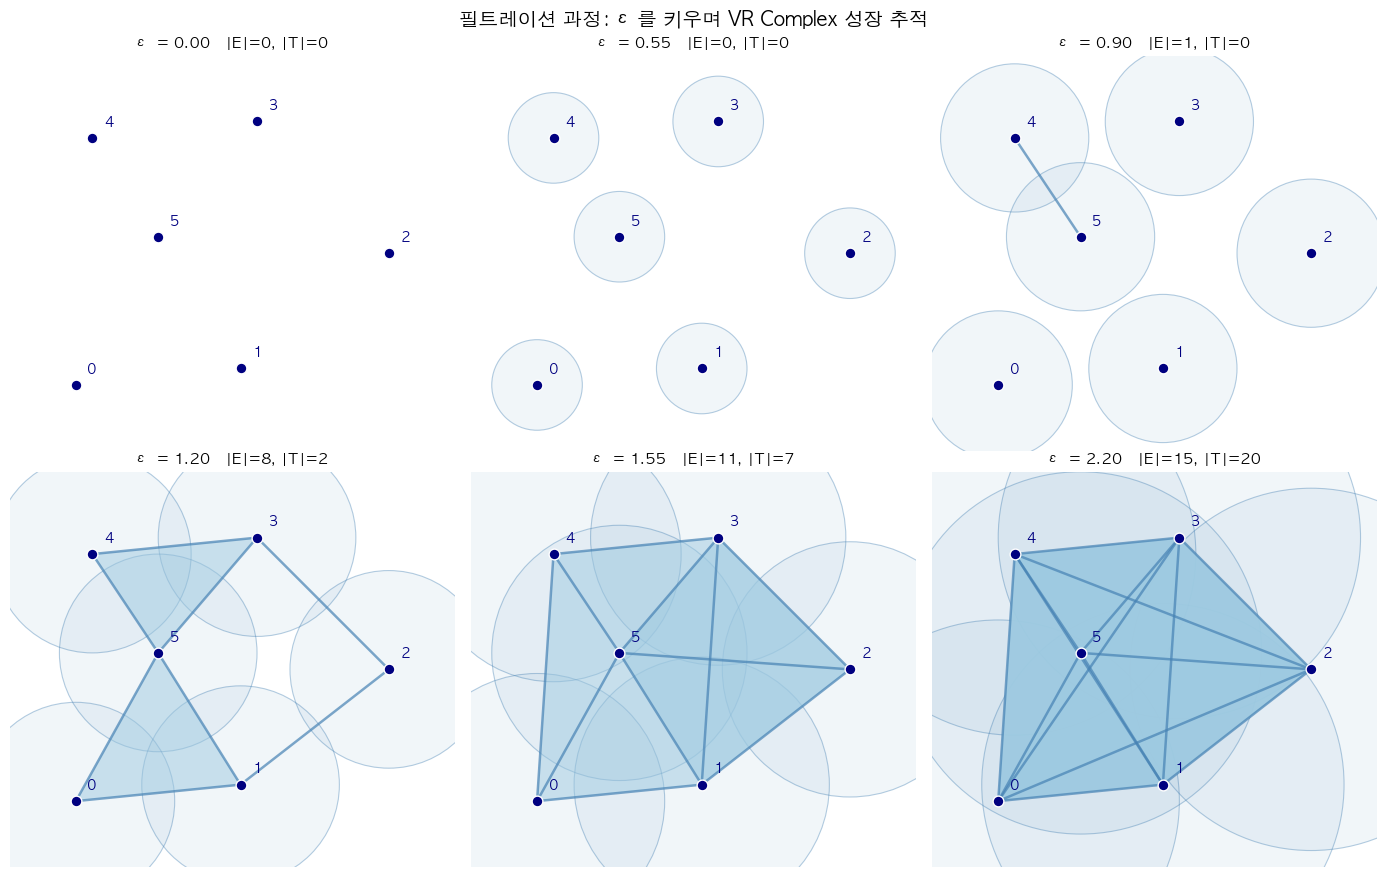

In [23]:
# ────────────────────────────────────────────────────────────
# § 4 필트레이션 단계별 시각화
# ────────────────────────────────────────────────────────────

# 작은 예제 (6점)로 필트레이션을 명확히 보여준다
np.random.seed(13)
X_small = np.array([
    [0.0, 0.0],
    [1.0, 0.1],
    [1.9, 0.8],
    [1.1, 1.6],
    [0.1, 1.5],
    [0.5, 0.9],
])
X_small -= X_small.mean(axis=0)

D_small = pairwise_dist(X_small)

# 전체 모서리 목록 (거리 기준 정렬)
all_edges = [(D_small[i,j], i, j) for i,j in combinations(range(len(X_small)),2)]
all_edges.sort()

print("📐 모서리 목록 (거리 기준 정렬):")
print(f"{'모서리':<12} {'거리':>8}")
print("-" * 22)
for d, i, j in all_edges:
    print(f"  ({i},{j})     {d:>8.3f}")

# 필트레이션 임계값 선택
epsilons_filt = [0.0, 0.55, 0.90, 1.20, 1.55, 2.20]
eps_labels = [f'ε={e}' for e in epsilons_filt]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("필트레이션 과정: ε를 키우며 VR Complex 성장 추적", fontsize=14)

pad = 0.4
xlim = (X_small[:,0].min()-pad, X_small[:,0].max()+pad)
ylim = (X_small[:,1].min()-pad, X_small[:,1].max()+pad)

for idx, (ax, eps) in enumerate(zip(axes.flat, epsilons_filt)):
    draw_vr_complex(ax, X_small, eps, show_circles=True)
    edges_now, tris_now = vr_complex(X_small, eps)
    
    # 꼭짓점 번호 표시
    for vi, (x, y) in enumerate(X_small):
        ax.text(x+0.07, y+0.07, str(vi), fontsize=10, color='navy', fontweight='bold')
    
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_title(f"ε = {eps:.2f}   |E|={len(edges_now)}, |T|={len(tris_now)}", fontsize=11)

plt.tight_layout()
plt.savefig('/tmp/fig_filtration.png', dpi=130, bbox_inches='tight')
plt.show()


---
## § 5  Persistent Homology — "얼마나 오래 살아남는가?"

### 핵심 아이디어

필트레이션을 수행하면서 각 위상적 특징(구멍 등)의 **탄생(birth)**과 **소멸(death)**을 추적합니다.

- **Birth (탄생)** : 새로운 위상 특징이 처음 나타나는 ε 값  
- **Death (소멸)** : 그 위상 특징이 사라지는(채워지는) ε 값  
- **Persistence (지속성)** : death − birth → **클수록 "진짜 신호"**, **작을수록 노이즈**

### 예시: 원형 데이터

| ε 범위 | 사건 |
|--------|------|
| ε = 0 | n개의 고립된 점, β₀ = n |
| ε 증가 | 점들이 연결되며 β₀ 감소 (H₀ 특징들이 하나씩 소멸) |
| ε ≈ r (원의 반지름) | 완전한 루프 형성, β₁ = 1 탄생 |
| ε ≫ r | 삼각형들이 루프를 채움, β₁ = 0 소멸 |

### Persistence Pair

$$\text{pair} = (b, d) \quad b < d$$

- H₀ pair: (꼭짓점 탄생 시각, 연결되는 모서리 시각)  
- H₁ pair: (루프 생성 모서리 시각, 루프 소멸 삼각형 시각)  
- **Essential class**: death = ∞ (마지막까지 살아남는 특징)


## *Move to `tutorial_TDA.ipynb`*